In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve
import joblib

In [3]:
df = pd.read_csv("TitanicDataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [14]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
df.rename(columns={'SibSp': 'SiblingsSpouses', 'Parch': 'ParentsChildren'}, inplace=True)

In [16]:
df['Age'].mean()

29.69911764705882

In [17]:
df['Age'].min()

0.42

In [18]:
df.corr(numeric_only= True)

,PassengerId,Survived,Pclass,Age,SiblingsSpouses,ParentsChildren,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SiblingsSpouses,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
ParentsChildren,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [19]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [20]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
df_backup = df.copy()

In [22]:
df.drop(columns=['Cabin'], inplace = True)

In [23]:
df['Age']= df['Age'].astype(int)

In [24]:
df.dtypes

PassengerId          int64
Survived             int64
Pclass               int64
Name                object
Sex                 object
Age                  int32
SiblingsSpouses      int64
ParentsChildren      int64
Ticket              object
Fare               float64
Embarked            object
dtype: object

In [25]:
df['Age'].unique()

array([22, 38, 26, 35, 28, 54,  2, 27, 14,  4, 58, 20, 39, 55, 31, 34, 15,
        8, 19, 40, 66, 42, 21, 18,  3,  7, 49, 29, 65,  5, 11, 45, 17, 32,
       16, 25,  0, 30, 33, 23, 24, 46, 59, 71, 37, 47, 70, 12,  9, 36, 51,
       44,  1, 61, 56, 50, 62, 41, 52, 63, 43, 60, 10, 64, 13, 48, 53, 57,
       80,  6, 74])

In [26]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [27]:
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SiblingsSpouses    0
ParentsChildren    0
Ticket             0
Fare               0
Embarked           0
dtype: int64

In [28]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

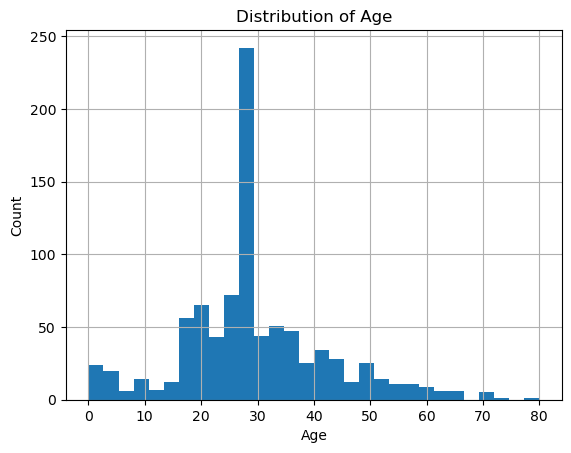

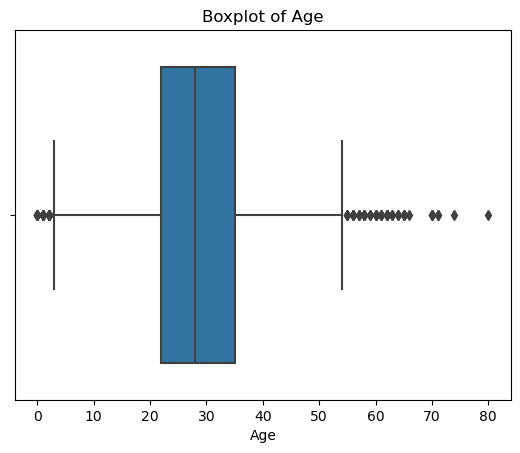

In [30]:
df['Age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.show()

Sex
0    577
1    314
Name: count, dtype: int64


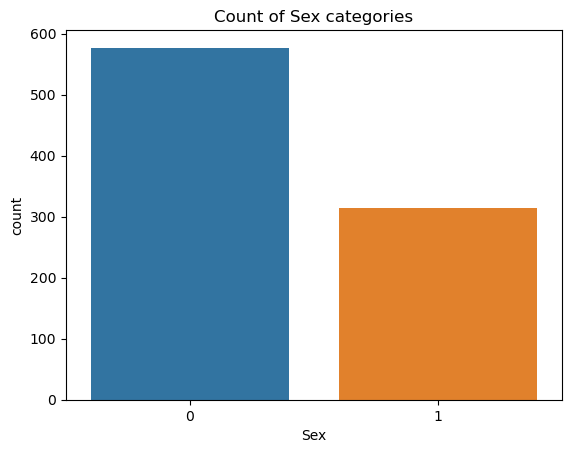

In [31]:
print(df['Sex'].value_counts())

sns.countplot(x='Sex', data=df)
plt.title('Count of Sex categories')
plt.show()


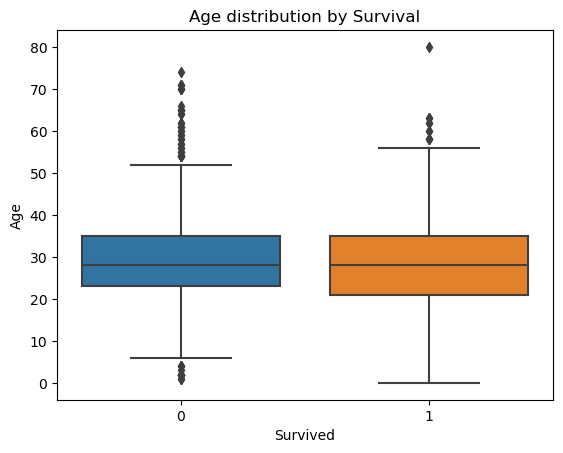

In [32]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age distribution by Survival')
plt.show()


AttributeError: 'numpy.int64' object has no attribute 'startswith'

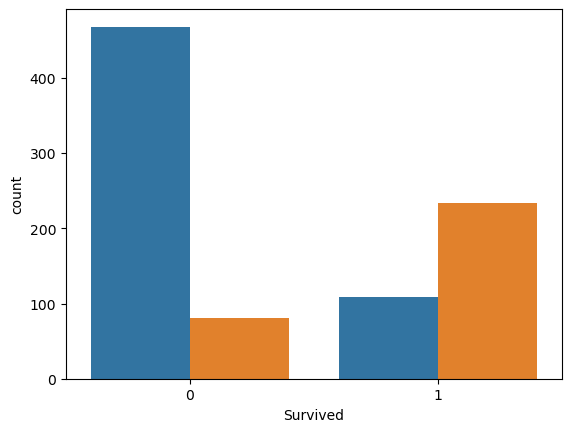

In [34]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival counts by Sex')
plt.show()

In [35]:
survival_rates = pd.crosstab(df['Pclass'], df['Survived'], normalize='index')
print(survival_rates)

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


                 PassengerId  Survived    Pclass       Sex       Age  \
PassengerId         1.000000 -0.005007 -0.035144 -0.042939  0.034322   
Survived           -0.005007  1.000000 -0.338481  0.543351 -0.064909   
Pclass             -0.035144 -0.338481  1.000000 -0.131900 -0.339999   
Sex                -0.042939  0.543351 -0.131900  1.000000 -0.080750   
Age                 0.034322 -0.064909 -0.339999 -0.080750  1.000000   
SiblingsSpouses    -0.057527 -0.035322  0.083081  0.114631 -0.233066   
ParentsChildren    -0.001652  0.081629  0.018443  0.245489 -0.172745   
Fare                0.012658  0.257307 -0.549500  0.182333  0.096838   
Embarked_Q         -0.033606  0.003650  0.221009  0.074115 -0.031479   
Embarked_S          0.022204 -0.149683  0.074053 -0.119224 -0.006237   

                 SiblingsSpouses  ParentsChildren      Fare  Embarked_Q  \
PassengerId            -0.057527        -0.001652  0.012658   -0.033606   
Survived               -0.035322         0.081629  0.2573

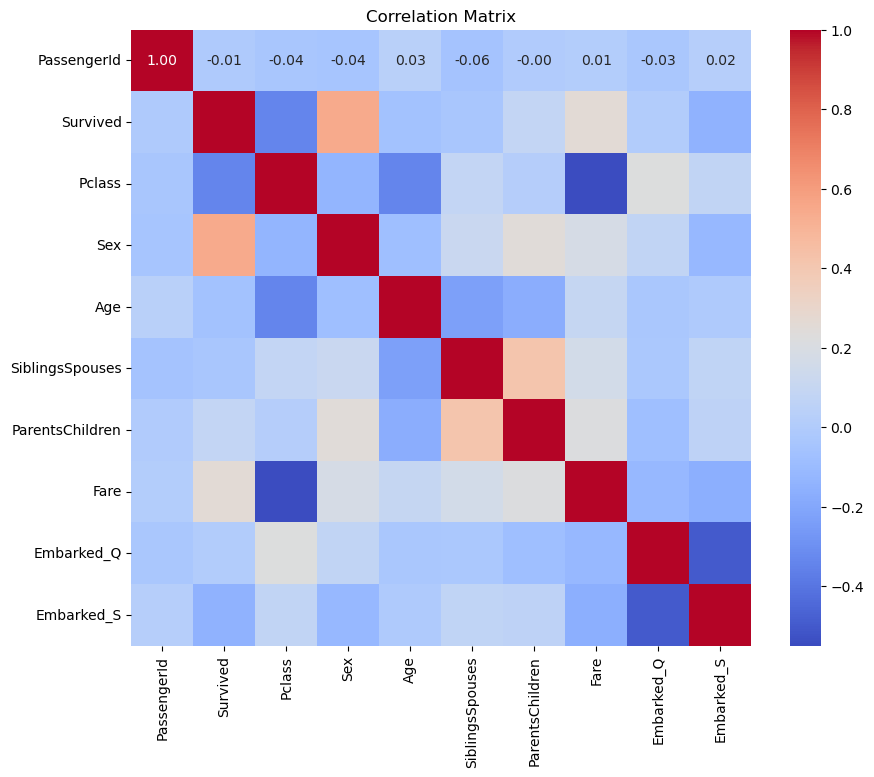

In [36]:
# Only compute correlation for numeric columns
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


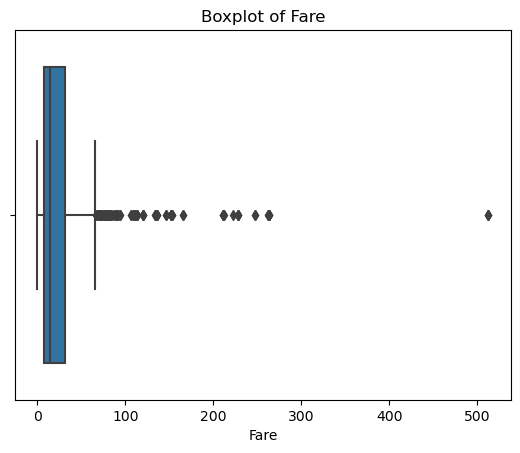

In [37]:
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare')
plt.show()


In [38]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Fare'] < Q1 - 1.5 * IQR) | (df['Fare'] > Q3 + 1.5 * IQR)]
print(f"Number of outliers in Fare: {outliers.shape[0]}")


Number of outliers in Fare: 116


Skewness of Fare: 4.7792532923723545


D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


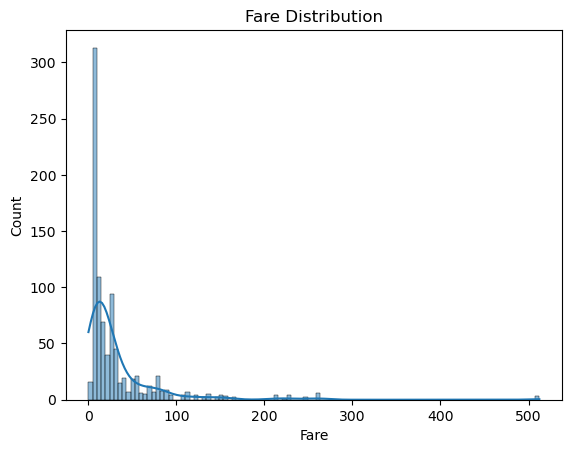

D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


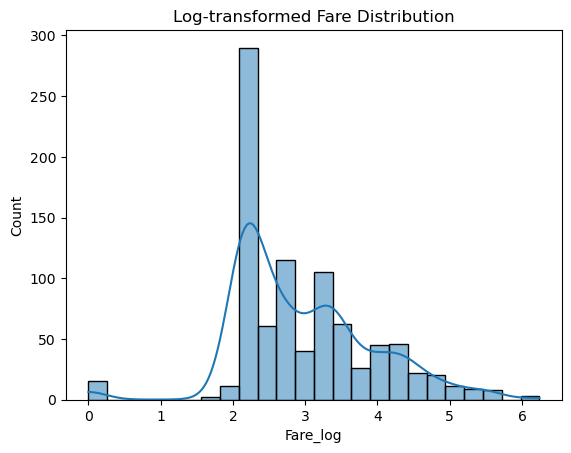

In [40]:
print("Skewness of Fare:", skew(df['Fare'].dropna()))

sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

# If skewed, apply log transform
df['Fare_log'] = np.log1p(df['Fare'])

sns.histplot(df['Fare_log'], kde=True)
plt.title('Log-transformed Fare Distribution')
plt.show()


In [41]:
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


In [42]:
# Group rare titles together
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

print(df['Title'].value_counts())


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       23
Mlle        2
Mme         1
Ms          1
Name: count, dtype: int64


In [43]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
       'SiblingsSpouses', 'ParentsChildren', 'Ticket', 'Fare', 'Embarked_Q',
       'Embarked_S', 'Fare_log', 'Title'],
      dtype='object')

In [46]:
df['FamilySize'] = df['SiblingsSpouses'] + df['ParentsChildren'] + 1

In [47]:
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\New folder\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

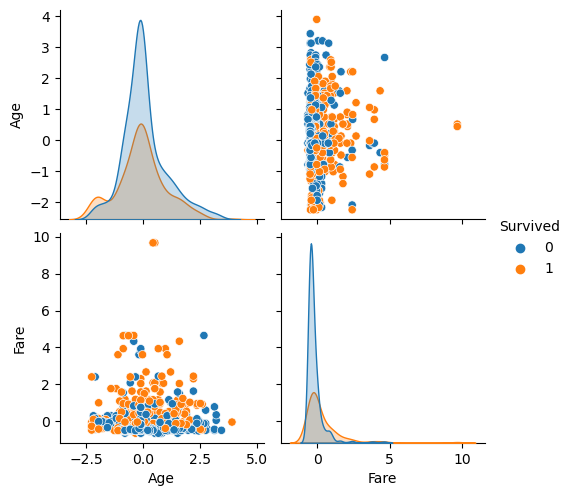

In [48]:
sns.pairplot(df[['Age', 'Fare', 'Survived']], hue='Survived')

In [49]:
df.to_csv('cleaned_dataset.csv', index=False)

In [50]:
# Drop only 'Name' and 'Ticket' (too unique)
df = df.drop(['Name', 'Ticket'], axis=1)

# Encode 'Title' if you think it's useful
df = pd.get_dummies(df, columns=['Title'], drop_first=True)


In [51]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)


In [52]:
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [54]:

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Accuracy: 0.7932960893854749
Confusion Matrix:
 [[87 18]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [56]:


# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Evaluate them
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Random Forest Accuracy: 0.8491620111731844
SVM Accuracy: 0.5865921787709497


In [58]:

cv_scores = cross_val_score(RandomForestClassifier(), X, y, cv=5)
print("Cross-validated accuracy:", cv_scores.mean())


Cross-validated accuracy: 0.8059067227418242


In [61]:

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8314291342460356


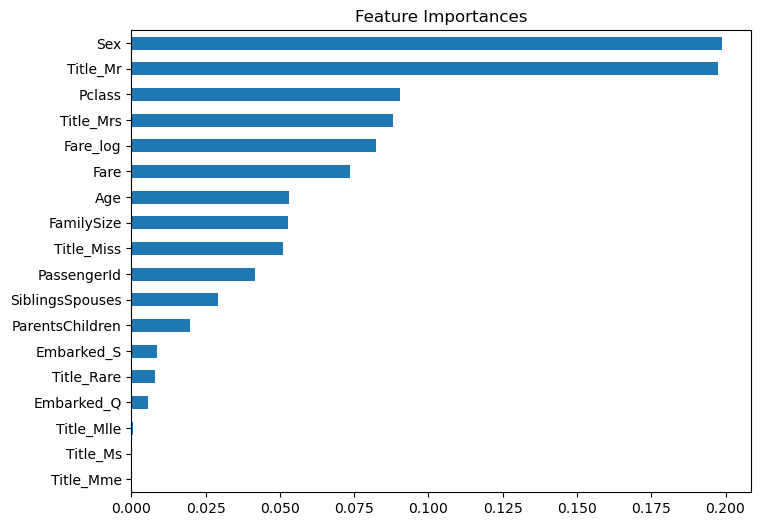

In [62]:
importances = pd.Series(grid.best_estimator_.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances")
plt.show()

In [63]:

# Use the best params from your tuning
best_params = {
    'max_depth': 5,
    'min_samples_split': 2,
    'n_estimators': 200,
    'random_state': 42
}

rf_best = RandomForestClassifier(**best_params)

# Train on training data
rf_best.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [65]:

# Predict on test set
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]  # Probability estimates for positive class

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8212290502793296
ROC-AUC Score: 0.8916344916344916
Confusion Matrix:
 [[93 12]
 [20 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



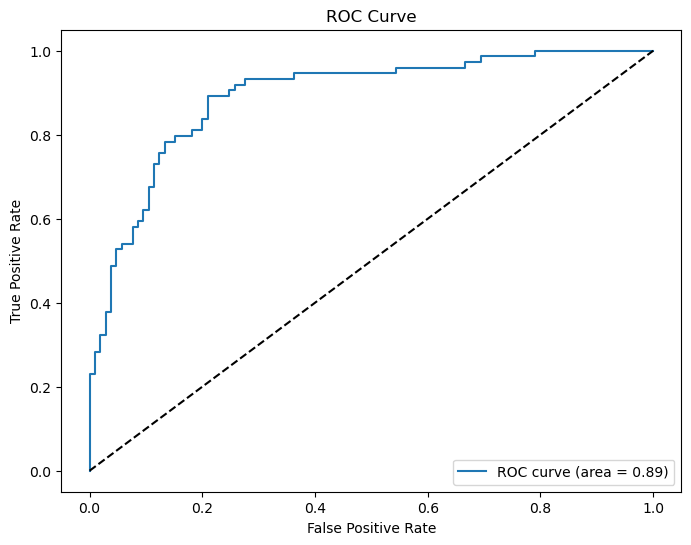

In [68]:

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


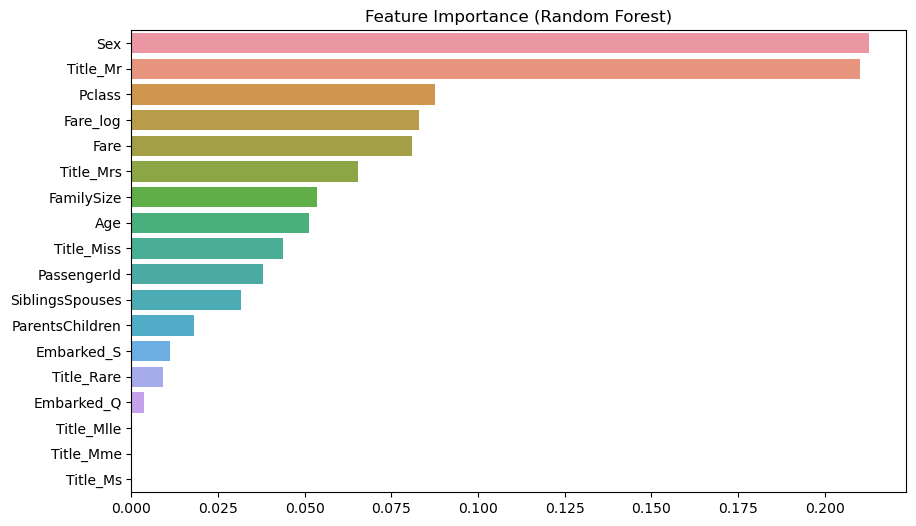

In [69]:
# Get feature importances
importances = rf_best.feature_importances_
feature_names = X_train.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importance (Random Forest)")
plt.show()


In [71]:
joblib.dump(rf_best, 'random_forest_titanic_model.pkl')
print("Model saved as 'random_forest_titanic_model.pkl'")

Model saved as 'random_forest_titanic_model.pkl'
